# 전차와 일반 자동차 인식

주어진 폴더(`data/tank_car`)에 있는 이미지 파일들을 처리하여 각 파일별로 나타난 전차와 일반 자동차의 수를 인식하는 것이 이번 문제의 목표입니다.

YOLOv8 모델을 사용하는 것을 기본으로 합니다. 단 YOLOv8 모델은 tank를 인식하지 못하기에 tank가 일반적으로 어떤 객체 타입으로 인식되는지 확인해보고 그 특징을 이용하여 일반 자동차(car)와 다르게 인식하는 방법을 추천합니다.

## 입력 데이터의 내용

입력 폴더는 `data/tank_car`에 있으며, 이 안에는 `imageNNN` 형식으로 된 400개의 이미지 파일이 있습니다. 여기서 `NNN`은 1부터 시작하는 세 자리 숫자입니다. 즉 첫번째 이미지 파일의 이름은 `image001`이 됩니다. 이미지 파일의 파일 확장자가 다를 수 있습니다 (대부분 png, jpg, jpeg입니다). 파일 이름은 다르지만 동일한 내용을 갖는 중복 이미지들이 일부 존재할 수 있습니다. 참고로 일반 자동차와 전차가 동시에 한 이미지에 존재하는 경우는 없고 하나가 아닌 다수의 전차나 자동차가 한 이미지에 나타날 수 있습니다. 아래 이미지 2개를 예시로 보였습니다. 일반 자동차 혹은 전차가 일부 잘려 있어도 해당 객체의 수를 세야 합니다.

<img src='data/tank_car/image001.jpg'>
<img src='data/tank_car/image005.jpg'>

## 초기코드

아래 초기 코드를 모두 실행하여 패키지를 설치한 후 반드시 커널을 재시작해야 합니다. `Kernel → Restart`

In [ ]:
# 🧱 Step 1: YOLOv8 설치
!pip uninstall pandas numpy -y
!pip install ultralytics numpy==1.26.4 pandas==2.2.2

Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached pandas-2.2.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (19 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
Using cached pandas-2.2.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.7 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is

In [ ]:
# PyTorch 완전히 제거 후 재설치
!pip uninstall torch torchvision torchaudio -y
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Found existing installation: torch 2.5.1+cu121
Uninstalling torch-2.5.1+cu121:
  Successfully uninstalled torch-2.5.1+cu121
Found existing installation: torchvision 0.20.1+cu121
Uninstalling torchvision-0.20.1+cu121:
  Successfully uninstalled torchvision-0.20.1+cu121
Found existing installation: torchaudio 2.5.1+cu121
Uninstalling torchaudio-2.5.1+cu121:
  Successfully uninstalled torchaudio-2.5.1+cu121
Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached https://download.pytorch.org/whl/cpu/torch-2.8.0%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (29 kB)
  Using cached https://download.pytorch.org/whl/cpu/torchvision-0.23.0%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (6.1 kB)
  Using cached https://download.pytorch.org/whl/cpu/torchaudio-2.8.0%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (7.2 kB)
Using cached https://download.pytorch.org/whl/cpu/torch-2.8.0%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl (183.9 MB)
Using cached https://download

## 최종 제출 파일

위 폴더(`data/tank_car`) 내의 파일들을 하나씩 읽어서 이를 처리하고 인식된 일반 자동차와 전차의 수를 이미지 파일의 이름과 함께 아래와 같은 형태의 CSV 파일로 저장하고 파일의 이름은 `submission.csv`라고 지정합니다. 이때 결과는 이미지 번호(NNN)를 기준으로 오름차순 정렬되어야 합니다. 아래는 `submission.csv` 파일의 처음 5개 이미지 결과를 보여주는 예시입니다.(포맷을 보여주기 위한 예일 뿐입니다.)

| filename | car | tank |
| --- | --- | --- |
| image001.jpg | 1 | 0 |
| image002.jpg | 1 | 0 |
| image003.jpeg | 0 | 2 |
| image004.jpg | 0 | 1 |
| image005.jpg | 0 | 1 |

 - filename: 이미지 파일명
 - car: 해당 이미지에서 탐지된 일반 자동차 수
 - tank: 해당 이미지에서 탐지된 전차 수

## 평가 기준

제출한 결과는 정확도(Accuracy)를 기준으로 계산합니다. 즉, 이미지별로 car와 tank의 개수가 정확히 맞은 퍼센트를 점수로 사용합니다.

In [32]:
# MAICON 2025 예선 문제 1 - 전차/자동차 개수 세기 (이미지별 개수 완전 일치 Accuracy)
# 전략: ① YOLOv8x 검출로 '차량 개수' 세기  ② YOLOv8x-cls(ImageNet, 'tank' 클래스 보유)로 '이미지 종류' 판정
#       ③ 검출 클래스 분포(truck/train/boat 등 = 전차 단서)를 보조 신호로 결합
import os, re, hashlib
from pathlib import Path
import numpy as np, pandas as pd, torch
from PIL import Image
from ultralytics import YOLO

IMG_DIR = Path("./problem_1_data/data/tank_car")
OUT_CSV = "./problem_1_data/submission.csv"
DEVICE  = 0 if torch.cuda.is_available() else "cpu"

# ===== 하이퍼파라미터 =====
DET_MODEL  = "yolov8x.pt"       # 가장 큰 모델: 학습이 없는 문제라 추론 정확도가 곧 점수
CLS_MODEL  = "yolov8x-cls.pt"   # ImageNet 1000 클래스에 'tank'가 있음
IMGSZ      = 640                # COCO 학습 해상도와 동일
CONF       = 0.48               # 잘린 차량까지 잡되 오검출 억제
IOU        = 0.50               # 같은 차량 중복 박스 제거
AGNOSTIC   = True               # 전차가 truck+car로 동시에 잡히는 이중 카운트 방지
AREA_RATIO = 0.10               # 최대 박스 면적의 10% 미만은 배경 차량으로 보고 제외
VEHICLE_IDS = {2: "car", 3: "motorcycle", 4: "airplane", 5: "bus", 6: "train", 7: "truck", 8: "boat"}
TANK_HINT_IDS = {4, 6, 7, 8}    # COCO에서 전차가 주로 오인되는 클래스
TANK_KW = {"tank", "half_track", "cannon", "amphibian", "amphibious_vehicle"}   # 정확히 일치하는 이름만 사용
CAR_KW  = {"sports_car", "convertible", "beach_wagon", "station_wagon", "cab", "limousine", "minivan",
           "jeep", "pickup", "racer", "grille", "car_wheel", "model_t", "car_mirror", "minibus"}

det = YOLO(DET_MODEL)
cls = YOLO(CLS_MODEL)
cls_names = {i: n.lower().replace(" ", "_") for i, n in cls.names.items()}
TANK_IDX = [i for i, n in cls_names.items() if n in TANK_KW]
CAR_IDX  = [i for i, n in cls_names.items() if n in CAR_KW]
print("tank 계열:", [cls_names[i] for i in TANK_IDX])
print("car 계열 :", [cls_names[i] for i in CAR_IDX])

def num(p): return int(re.search(r"(\d+)", p.stem).group(1))
files = sorted([p for p in IMG_DIR.iterdir() if p.is_file() and not p.name.startswith(".")], key=num)

def load(p):
    try:
        return Image.open(p).convert("RGB")      # webp/png(RGBA) 포함 통일
    except Exception:
        return None                              # 손상/빈 파일

cache, rows = {}, []
for p in files:
    h = hashlib.md5(p.read_bytes()).hexdigest()
    if h in cache:                               # 내용이 같은 중복 이미지 → 동일 결과
        rows.append({"filename": p.name, **cache[h]}); continue
    img = load(p)
    if img is None:                              # 빈 파일(예: image372.png): 최빈 패턴인 1대로 처리
        res = {"car": 1, "tank": 0}; print("[WARN] unreadable:", p.name)
    else:
        # ---- ① 개수: 검출 ----
        b = det.predict(img, imgsz=IMGSZ, conf=CONF, iou=IOU, agnostic_nms=AGNOSTIC,
                        classes=list(VEHICLE_IDS), device=DEVICE, verbose=False)[0].boxes
        c = b.cls.cpu().numpy().astype(int); s = b.conf.cpu().numpy()
        wh = b.xywhn.cpu().numpy()[:, 2:]; area = wh[:, 0] * wh[:, 1]
        keep = area >= AREA_RATIO * area.max() if len(area) else np.array([], bool)
        c, s = c[keep], s[keep]
        n = max(int(len(c)), 1)                  # 모든 이미지에 최소 1대 존재

        # ---- ② 종류: 분류 확률 + ③ 검출 단서 ----
        prob = cls.predict(img, imgsz=224, device=DEVICE, verbose=False)[0].probs.data.cpu().numpy()
        p_tank, p_car = prob[TANK_IDX].sum(), prob[CAR_IDX].sum()
        det_tank = s[np.isin(c, list(TANK_HINT_IDS))].sum() / (s.sum() + 1e-6) if len(s) else 0.5
        score = (p_tank - p_car) + 0.3 * (det_tank - 0.5)   # 분류기 우선, 검출은 동점 깨기용
        is_tank = score > 0
        res = {"car": 0 if is_tank else n, "tank": n if is_tank else 0}
    cache[h] = res
    rows.append({"filename": p.name, **res})

sub = pd.DataFrame(rows, columns=["filename", "car", "tank"])
sub.to_csv(OUT_CSV, index=False)
print(sub.head(), "\n", sub[["car", "tank"]].sum().to_dict(), "| rows:", len(sub))

tank 계열: ['amphibian', 'cannon', 'half_track', 'tank']
car 계열 : ['beach_wagon', 'cab', 'car_mirror', 'car_wheel', 'convertible', 'grille', 'jeep', 'limousine', 'minibus', 'minivan', 'model_t', 'pickup', 'racer', 'sports_car']
[WARN] unreadable: image372.png
        filename  car  tank
0   image001.jpg    0     1
1   image002.jpg    1     0
2  image003.jpeg    3     0
3   image004.jpg    0     1
4   image005.jpg    1     0 
 {'car': 291, 'tank': 147} | rows: 400


In [33]:
import pandas as pd
#{데이터위치} << 파일경로 입력
# ---------- 1. 불러오기 ----------
truth = pd.read_csv('./{데이터위치}/tank_solution_real.csv').fillna(0)    # image150의 빈 tank 값은 0으로
pred = pd.read_csv('./{데이터위치}/submission.csv')            # 파일로 비교하려면: pd.read_csv('submission.csv')

assert len(truth) == len(pred) == 400
assert (truth['filename'].values == pred['filename'].values).all(), '파일명 순서가 다름'

m = truth.merge(pred, on='filename', suffixes=('_t', '_p'))

# ---------- 2. 전체 정확도 (대회 채점 방식: car, tank 둘 다 맞아야 정답) ----------
m['ok'] = (m['car_t'] == m['car_p']) & (m['tank_t'] == m['tank_p'])
print(f"정확도: {m['ok'].mean():.4f} ({m['ok'].sum()}/{len(m)})")

# ---------- 3. 종류별 분석 ----------
m['type_t'] = np.where(m['car_t'] > 0, 'car', 'tank')
m['type_p'] = np.select([m['car_p'] > 0, m['tank_p'] > 0], ['car', 'tank'], default='none')   # none = 아무것도 못 찾음

print('\n[종류 혼동행렬: 행=정답, 열=예측]')
print(pd.crosstab(m['type_t'], m['type_p']))
print('\n[정답 종류별 정확도]')
print(m.groupby('type_t')['ok'].mean())

# ---------- 4. 종류는 맞았는데 개수가 틀린 경우 ----------
tc = m[m['type_t'] == m['type_p']].copy()
tc['n_t'] = tc['car_t'] + tc['tank_t']
tc['n_p'] = tc['car_p'] + tc['tank_p']
print(f"\n종류 일치 시 개수 정확도: {(tc['n_t'] == tc['n_p']).mean():.4f} ({len(tc)}장)")
print(pd.crosstab(tc['n_t'], tc['n_p'], rownames=['정답 개수'], colnames=['예측 개수']))

# ---------- 5. 오답 목록 ----------
wrong = m[~m['ok']][['filename', 'car_t', 'tank_t', 'car_p', 'tank_p']]
print(f"\n오답 {len(wrong)}장")
print(wrong.to_string())

# ---------- 6. (선택) "못 찾으면 전차 1대" 규칙 적용 시 시뮬레이션 ----------
sim = m.copy()
none_mask = (sim['car_p'] == 0) & (sim['tank_p'] == 0)
sim.loc[none_mask, 'tank_p'] = 1
sim_ok = (sim['car_t'] == sim['car_p']) & (sim['tank_t'] == sim['tank_p'])
print(f"\n'못 찾으면 전차 1대' 적용 시: {sim_ok.mean():.4f} ({sim_ok.sum()}/{len(sim)})")

정확도: 0.9550 (382/400)

[종류 혼동행렬: 행=정답, 열=예측]
type_p  car  tank
type_t           
car     260     0
tank      1   139

[정답 종류별 정확도]
type_t
car     0.976923
tank    0.914286
Name: ok, dtype: float64

종류 일치 시 개수 정확도: 0.9574 (399장)
예측 개수    1   2  3
정답 개수            
1.0    359   5  0
2.0      9  17  1
3.0      0   2  6

오답 18장
         filename  car_t  tank_t  car_p  tank_p
87   image090.jpg      0     2.0      0       1
113  image117.jpg      0     1.0      0       2
118  image122.jpg      0     2.0      0       1
149  image153.jpg      0     1.0      0       2
159  image163.jpg      1     0.0      2       0
180  image184.jpg      0     2.0      0       1
181  image185.jpg      1     0.0      2       0
195  image199.jpg      3     0.0      2       0
211  image215.png      0     2.0      0       1
228  image232.jpg      0     1.0      0       2
249  image254.jpg      0     2.0      0       1
270  image275.jpg      0     2.0      0       1
332  image337.png      0     2.0      0       1
33

In [22]:
print(len(wrong))
print(wrong['filename'].head(10).tolist())
print('image039.jpg' in set(wrong['filename']))

18
['image090.jpg', 'image117.jpg', 'image122.jpg', 'image153.jpg', 'image163.jpg', 'image184.jpg', 'image185.jpg', 'image199.jpg', 'image215.png', 'image232.jpg']
False


/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


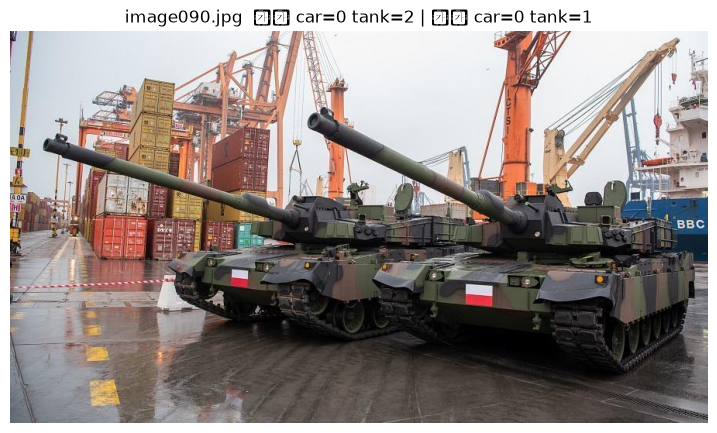

image039.jpg는 현재 오답 목록에 없습니다 (지금 오답 18장)


In [25]:
BASE_DIR = './problem_1_data/data/tank_car'

def show(fn=None, i=None):
    """fn: 파일명 또는 i: wrong 안에서의 순번(0부터)"""
    if fn is not None:
        hit = wrong[wrong['filename'] == fn]
        if hit.empty:
            print(f'{fn}는 현재 오답 목록에 없습니다 (지금 오답 {len(wrong)}장)'); return
        r = hit.iloc[0]
    else:
        r = wrong.iloc[i]; fn = r['filename']
    img = Image.open(os.path.join(BASE_DIR, fn)).convert('RGB')
    plt.figure(figsize=(9, 9)); plt.imshow(img); plt.axis('off')
    plt.title(f"{fn}  정답 car={int(r['car_t'])} tank={int(r['tank_t'])} | 예측 car={int(r['car_p'])} tank={int(r['tank_p'])}")
    plt.show()

show(i=0)                         # 현재 오답 첫 번째
show(fn='image039.jpg')           # 목록에 없으면 안내 메시지만 출력

## 결과 저장

채점을 위해, 위에서 구한 데이터를 현재 파일과 같은 디렉토리(.ipynb 파일이 있는 디렉토리)에 `submission.csv`이라는 이름으로 저장해 주세요.

# Task
Generate Python code to process images in the "data/tank_car" directory using a pre-trained YOLOv8 model, count the number of cars and tanks in each image, and save the results to a CSV file named "submission.csv". The output CSV should contain the image filename, the count of cars, and the count of tanks, sorted by image number. Tanks should be identified based on the YOLOv8 model's output, potentially by recognizing them as a different object class.

## 데이터 준비

### Subtask:
`data/tank_car` 폴더에서 이미지 파일 목록을 가져옵니다.


**Reasoning**:
Import the `os` module and list and filter image files from the specified directory.



In [ ]:
import os

image_dir = 'data/tank_car'
image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
image_files.sort() # Sort the files by name (image number)
print(f"Found {len(image_files)} image files.")

FileNotFoundError: [Errno 2] No such file or directory: 'data/tank_car'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
